## Geomodeling benchmark: the “Claudius”-Model
- The bottom layer with complex geometry

In [15]:
import geoinr_faults as grf

Define the model conditions

In [16]:
geomodel = grf.create_geomodel(
    project_name='Claudius',
    extent=[548800, 552500, 7816600, 7822000, -11010, -8400],
    resolution=[200, 100, 200],
    path_to_surface_points='input_data/Claudius/Claudius_interface.csv',
    path_to_orientations=None, 
)

In [17]:
geomodel

GeoModel('Claudius', extent=[548800, 552500, 7816600, 7822000, -11010, -8400], resolution=[200, 100, 200], stratis=0, horizons=[], faults=0)

Add stratigraphy column

In [18]:
geomodel = grf.add_stratis(geomodel, strati_configs=[
    grf.StratiConfig(name="main_strati", formations=['Apoints', 'Bpoints', 'Cpoints', 'Dpoints']),
])

In [19]:
geomodel

GeoModel('Claudius', extent=[548800, 552500, 7816600, 7822000, -11010, -8400], resolution=[200, 100, 200], stratis=1, horizons=[4], faults=0)

[warn] No orientation points/vectors found; orientation visualization skipped.


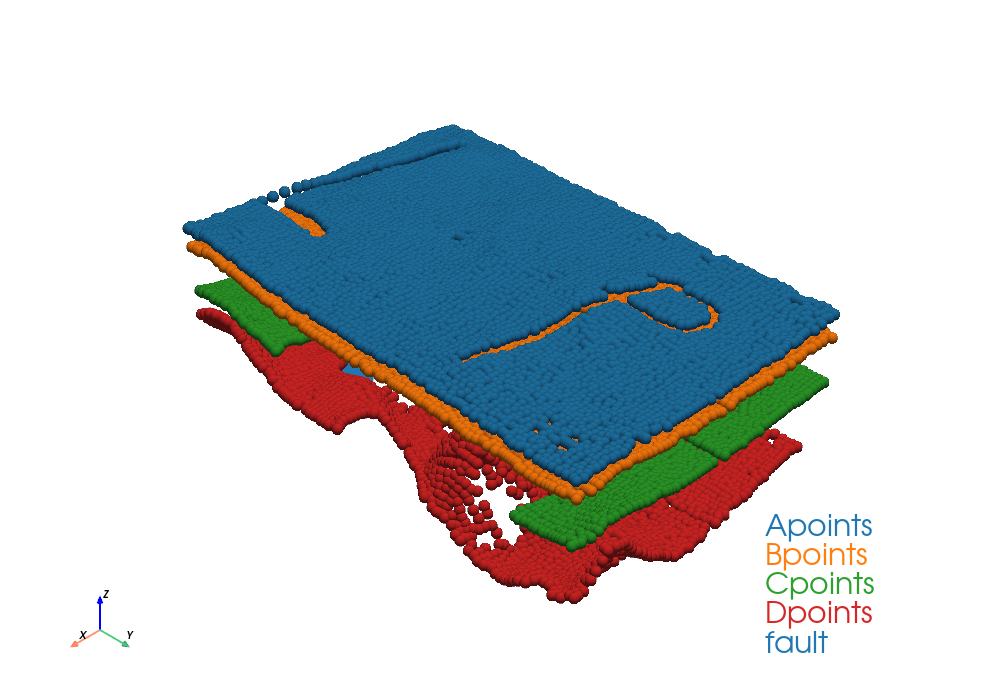

In [20]:
grf.plot_input_data(geomodel, notebook=True, legend_size=(0.22, 0.22), camera_position=None)

Add faults, here the fault trunction rules are used, if `truncation` is true, need to define the truncting fault

In [21]:
geomodel = grf.add_faults(geomodel, fault_configs=[
    grf.FaultConfig(name='fault', lx=1100, ly=500, lz=2000, X0=551300, Y0=7816600, Z0=-10200,
                   dmax=1, lam=0.5, Normal_fault=False),
])

In [22]:
geomodel

GeoModel('Claudius', extent=[548800, 552500, 7816600, 7822000, -11010, -8400], resolution=[200, 100, 200], stratis=1, horizons=[4], faults=1)

Visualization of fault feature fields

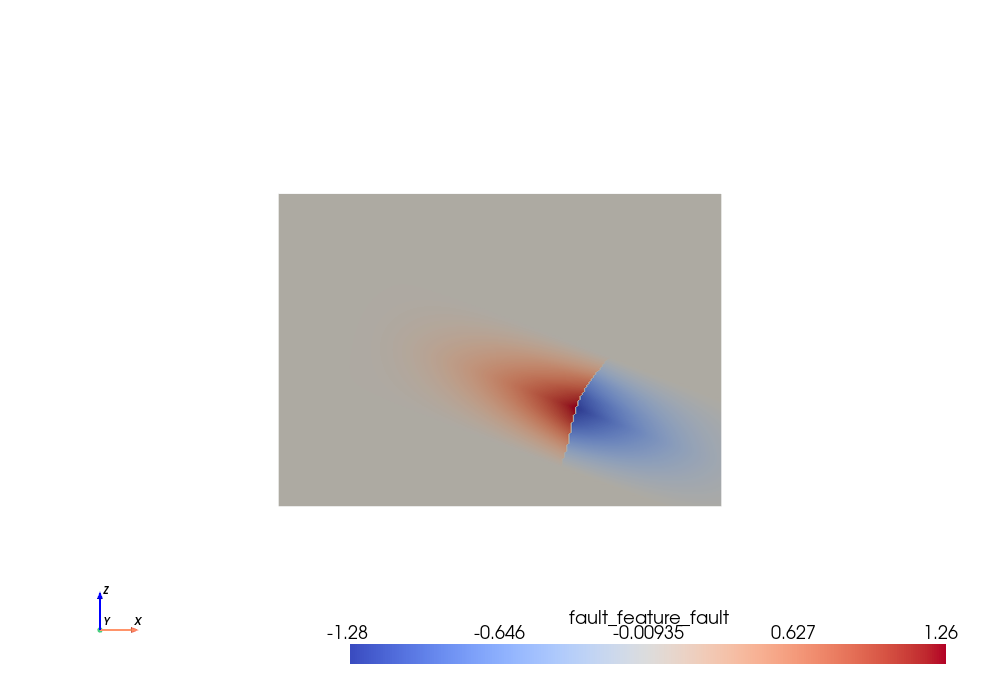

In [23]:
grf.plot_fault_features(geomodel, fault_name='fault', cmap='coolwarm', notebook=True, camera_position='xz')

Visualizing fault surfaces

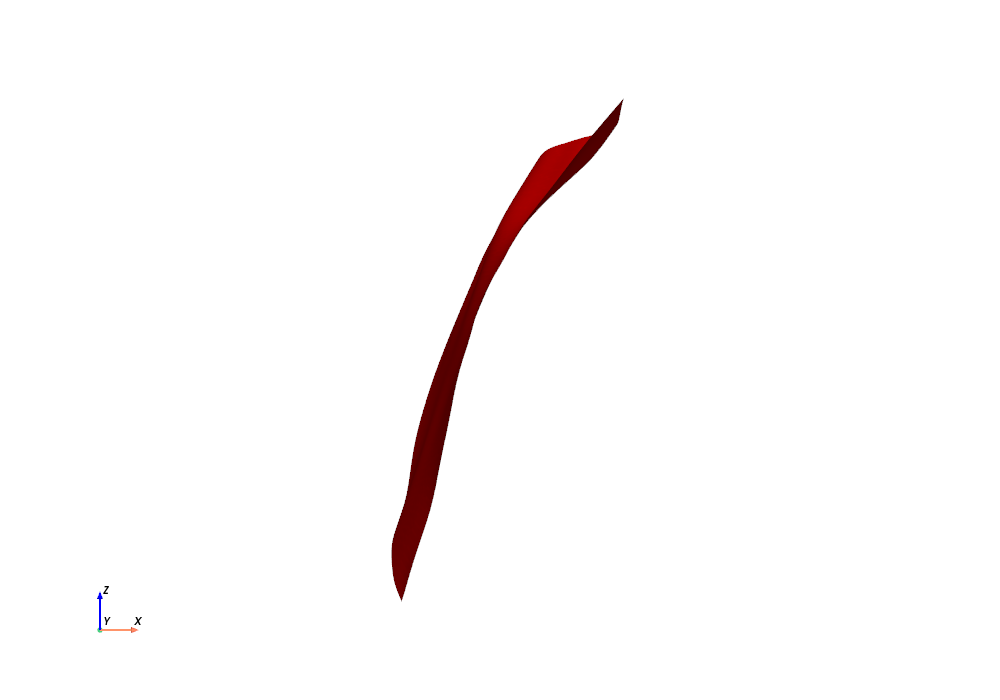

In [24]:
grf.plot_fault_meshes(geomodel, notebook=True, camera_position='xz')

Compute model

In [25]:
results = grf.compute_model(
    geomodel,
    nn_model='mlp',          # 'mlp' | 'siren' | 'resnet'  or custom class
    hidden_dim=256,
    n_layers=2,
    activation='softplus',   # 'softplus' | 'relu' | 'tanh' | 'sine' | ...
    softplus_beta=200,
    epochs=3000,
    lr=1e-3,
    #seed=0,
)

Epoch [500/3000]  Loss: 0.0429  Var: 0.0001  On: 0.0428  Above: 0.0000  Below: 0.0000  Orie: 0.0000  Best: 0.0385
Epoch [1000/3000]  Loss: 0.0325  Var: 0.0001  On: 0.0324  Above: 0.0000  Below: 0.0000  Orie: 0.0000  Best: 0.0303
Epoch [1500/3000]  Loss: 0.0347  Var: 0.0001  On: 0.0346  Above: 0.0000  Below: 0.0000  Orie: 0.0000  Best: 0.0269
Epoch [2000/3000]  Loss: 0.0286  Var: 0.0001  On: 0.0285  Above: 0.0000  Below: 0.0000  Orie: 0.0000  Best: 0.0252
Epoch [2500/3000]  Loss: 0.0261  Var: 0.0001  On: 0.0260  Above: 0.0000  Below: 0.0000  Orie: 0.0000  Best: 0.0226
Epoch [3000/3000]  Loss: 0.0225  Var: 0.0001  On: 0.0225  Above: 0.0000  Below: 0.0000  Orie: 0.0000  Best: 0.0202

Training finished in 34.6 s  |  Best loss: 0.0202
Inference completed in 0.0040 s


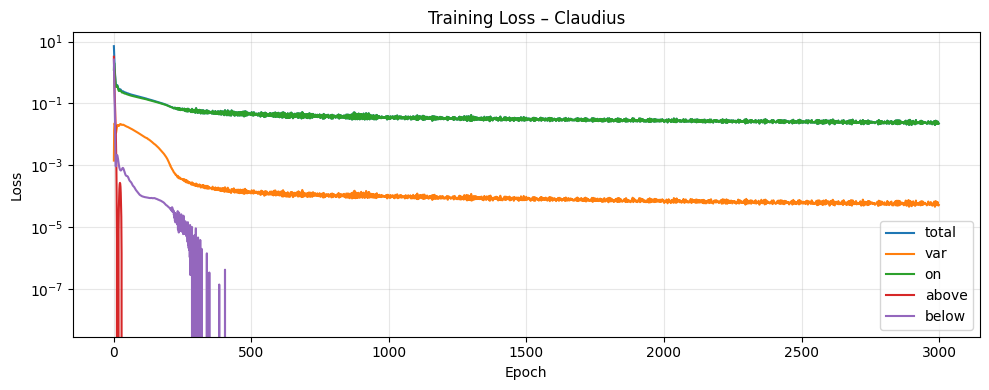

In [26]:
grf.plot_loss(results)

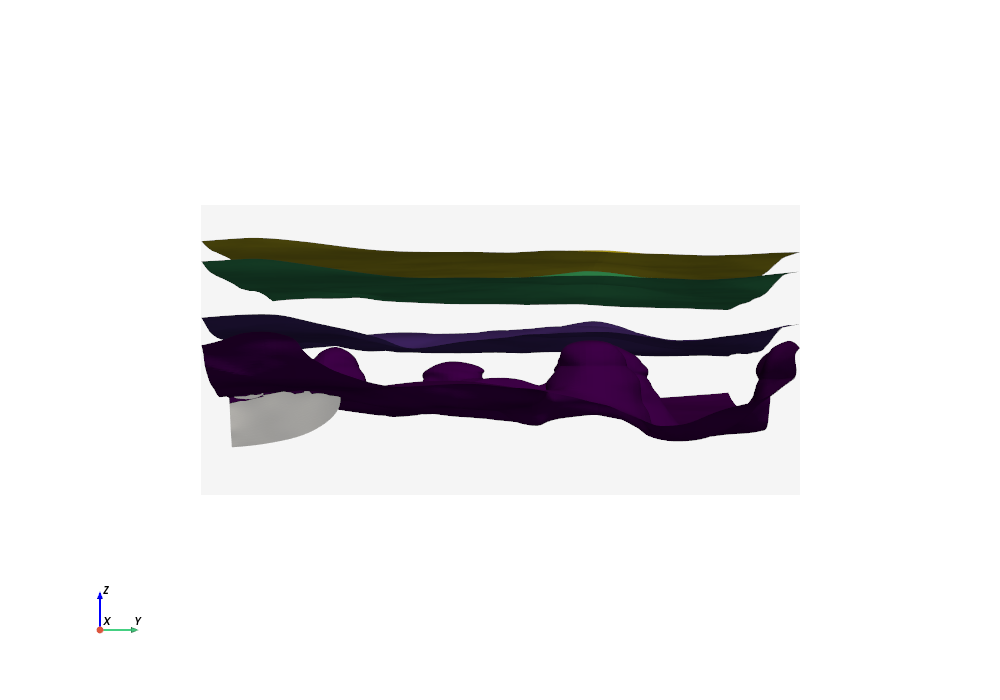

In [27]:
grf.plot_model(results, notebook=True, show_scalar_field=False, show_isosurfaces=True, show_fault_meshes=True, camera_position='yz')

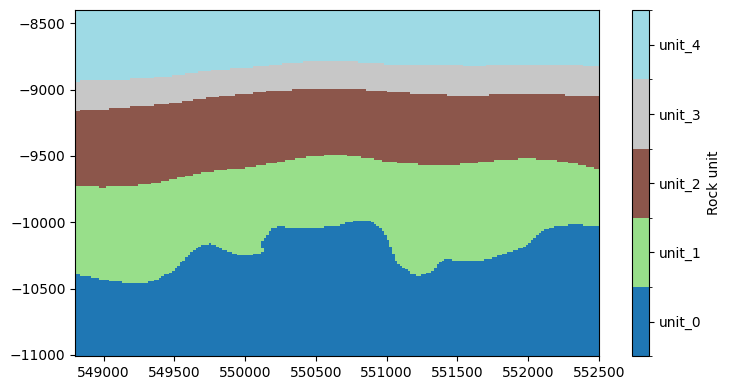

In [28]:
grf.plot_section_rock_unit(results, axis='y',figsize=(7.5, 4))